In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('rfm_data.csv')
df.head()

,Customer_ID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,3,7,4310.00
2,12348,76,4,1797.24
3,12349,19,1,1757.55
4,12350,311,1,334.40


In [3]:
df.shape

(200, 4)

In [6]:
df.describe()

,Customer_ID,Recency,Frequency,Monetary
count,200.000000,200.000000,200.000000,200.000000
mean,12470.100000,90.125000,3.745000,3214.037700
std,73.097512,99.986227,4.484476,10574.126263
min,12346.000000,1.000000,1.000000,73.500000
25%,12408.750000,20.000000,1.000000,447.192500
50%,12469.500000,45.500000,2.000000,1031.760000
75%,12532.500000,114.750000,4.250000,2798.740000
max,12593.000000,367.000000,32.000000,124914.530000


In [7]:
df.dtypes

Customer_ID      int64
Recency          int64
Frequency        int64
Monetary       float64
dtype: object

In [9]:
df.isnull().sum()

Customer_ID    0
Recency        0
Frequency      0
Monetary       0
dtype: int64

In [10]:
# Remove extreme outliers
df = df[df['Monetary'] > 0]
df = df[df['Monetary'] < df['Monetary'].quantile(0.99)]
df = df[df['Frequency'] < df['Frequency'].quantile(0.99)]

print(f"Customers after removing outliers: {len(df)}")

Customers after removing outliers: 196


In [14]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df[['Recency', 'Frequency', 'Monetary']])
print(f"Shape: {rfm_scaled.shape}")

Shape: (196, 3)


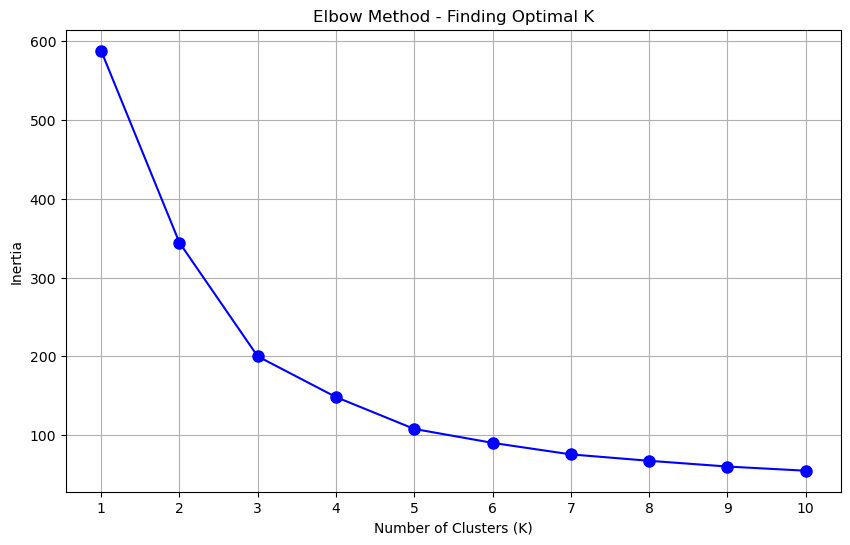

In [15]:
# Find optimal number of clusters
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Finding Optimal K')
plt.xticks(K)
plt.grid(True)
plt.show()

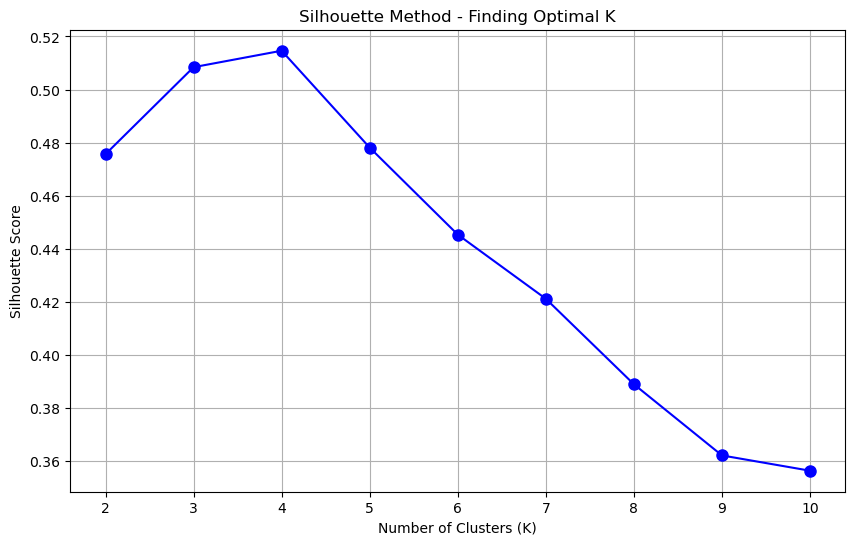

In [16]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(K, silhouette_scores, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method - Finding Optimal K')
plt.xticks(K)
plt.grid(True)
plt.show()

In [21]:
print(round(score,1))

0.4


In [22]:
# Apply K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(rfm_scaled)

# See cluster sizes
print(df['Cluster'].value_counts())

# See cluster characteristics
print(df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2))

Cluster
2    116
1     38
0     32
3     10
Name: count, dtype: int64
         Recency  Frequency  Monetary
Cluster                              
0          20.16       9.00   4366.25
1         270.92       1.42    548.14
2          53.60       2.27   1245.30
3          51.00       6.00  11179.23


In [23]:
# Label the clusters
cluster_labels = {
    0: 'Loyal Customers',
    1: 'Lost Customers',
    2: 'At Risk',
    3: 'Champions'
}

df['Segment'] = df['Cluster'].map(cluster_labels)

# See final result
print(df['Segment'].value_counts())
print(df.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2))

Segment
At Risk            116
Lost Customers      38
Loyal Customers     32
Champions           10
Name: count, dtype: int64
                 Recency  Frequency  Monetary
Segment                                      
At Risk            53.60       2.27   1245.30
Champions          51.00       6.00  11179.23
Lost Customers    270.92       1.42    548.14
Loyal Customers    20.16       9.00   4366.25


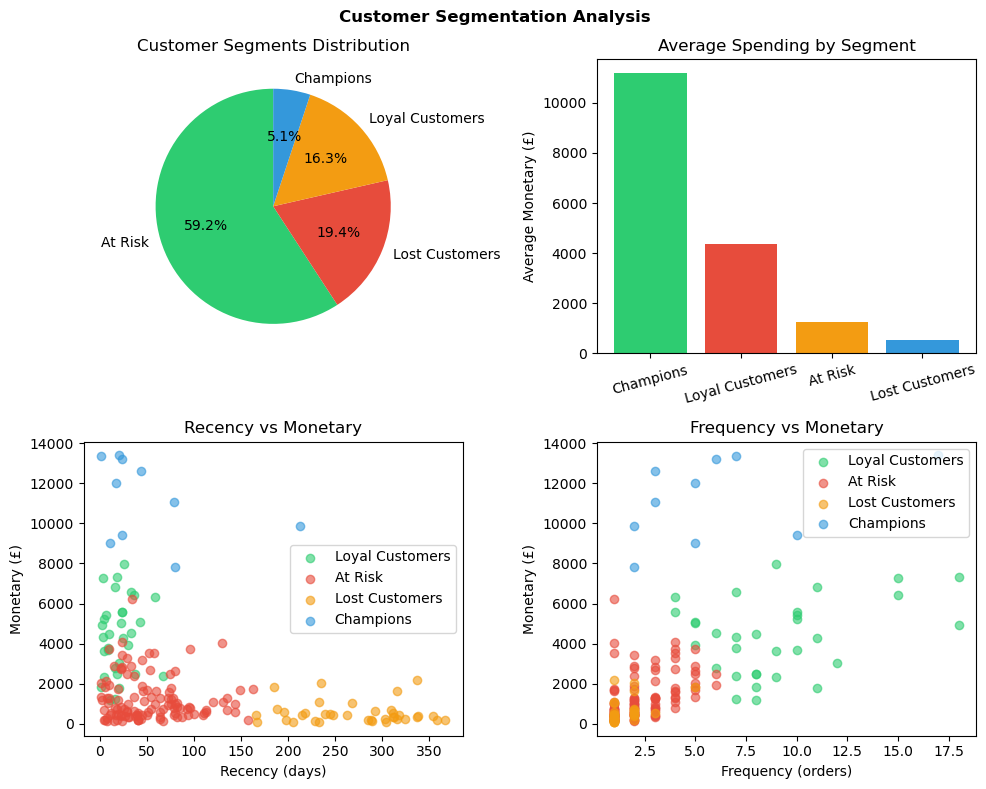

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Customer Segmentation Analysis', fontsize=12, fontweight='bold')
# 1. Cluster Size
ax1 = axes[0, 0]
segment_counts = df['Segment'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
ax1.pie(segment_counts, labels=segment_counts.index, 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Customer Segments Distribution')

# 2. Average Monetary by Segment
ax2 = axes[0, 1]
monetary_avg = df.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
ax2.bar(monetary_avg.index, monetary_avg.values, color=colors)
ax2.set_title('Average Spending by Segment')
ax2.set_ylabel('Average Monetary (£)')
ax2.tick_params(axis='x', rotation=15)

# 3. Recency vs Monetary
ax3 = axes[1, 0]
for segment, color in zip(df['Segment'].unique(), colors):
    mask = df['Segment'] == segment
    ax3.scatter(df[mask]['Recency'], df[mask]['Monetary'], 
                label=segment, alpha=0.6, color=color)
ax3.set_title('Recency vs Monetary')
ax3.set_xlabel('Recency (days)')
ax3.set_ylabel('Monetary (£)')
ax3.legend()

# 4. Frequency vs Monetary
ax4 = axes[1, 1]
for segment, color in zip(df['Segment'].unique(), colors):
    mask = df['Segment'] == segment
    ax4.scatter(df[mask]['Frequency'], df[mask]['Monetary'],
                label=segment, alpha=0.6, color=color)
ax4.set_title('Frequency vs Monetary')
ax4.set_xlabel('Frequency (orders)')
ax4.set_ylabel('Monetary (£)')
ax4.legend()

plt.tight_layout()
plt.savefig('customer_segmentation.png', dpi=300, bbox_inches='tight')
plt.show()